In [5]:
import requests

API_KEY = "e048242b4a8ecebada90737442280b09"
city = "Kathmandu"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)
data = response.json()
print(data)

{'coord': {'lon': 85.3167, 'lat': 27.7167}, 'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02d'}], 'base': 'stations', 'main': {'temp': 295.27, 'feels_like': 294.5, 'temp_min': 295.27, 'temp_max': 295.27, 'pressure': 1011, 'humidity': 37, 'sea_level': 1011, 'grnd_level': 850}, 'visibility': 10000, 'wind': {'speed': 1.54, 'deg': 270}, 'clouds': {'all': 20}, 'dt': 1775542032, 'sys': {'type': 1, 'id': 9201, 'country': 'NP', 'sunrise': 1775520168, 'sunset': 1775565524}, 'timezone': 20700, 'id': 1283240, 'name': 'Kathmandu', 'cod': 200}


In [13]:
import pandas as pd

weather = {
    'coord': {'lon': 85.3167, 'lat': 27.7167},
    'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02d'}],
    'base': 'stations',
    'main': {
        'temp': 295.27,
        'feels_like': 294.5,
        'temp_min': 295.27,
        'temp_max': 295.27,
        'pressure': 1011,
        'humidity': 37,
        'sea_level': 1011,
        'grnd_level': 850
    },
    'visibility': 10000,
    'wind': {'speed': 1.54, 'deg': 270},
    'clouds': {'all': 20},
    'dt': 1775542032,
    'sys': {
        'type': 1,
        'id': 9201,
        'country': 'NP',
        'sunrise': 1775520168,
        'sunset': 1775565524
    },
    'timezone': 20700,
    'id': 1283240,
    'name': 'Kathmandu',
    'cod': 200
}

df = pd.DataFrame([{
    "city": weather["name"],
    "country": weather["sys"]["country"],
    "temp_K": weather["main"]["temp"],
    "feels_like_K": weather["main"]["feels_like"],
    "humidity": weather["main"]["humidity"],
    "pressure": weather["main"]["pressure"],
    "clouds_percent": weather["clouds"]["all"],
    "wind_speed": weather["wind"]["speed"]
}])

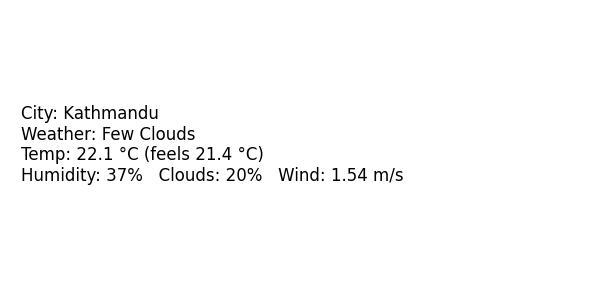

In [14]:
import matplotlib.pyplot as plt

city = df.loc[0, "city"]
temp_c = df.loc[0, "temp_K"] - 273.15
feels_c = df.loc[0, "feels_like_K"] - 273.15
humidity = df.loc[0, "humidity"]
clouds = df.loc[0, "clouds_percent"]
wind = df.loc[0, "wind_speed"]
weather_desc = weather["weather"][0]["description"].title()

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")

text = (
    f"City: {city}\n"
    f"Weather: {weather_desc}\n"
    f"Temp: {temp_c:.1f} °C (feels {feels_c:.1f} °C)\n"
    f"Humidity: {humidity}%   Clouds: {clouds}%   Wind: {wind} m/s"
)

ax.text(0.02, 0.5, text, fontsize=12, va="center")
plt.tight_layout()
plt.show()

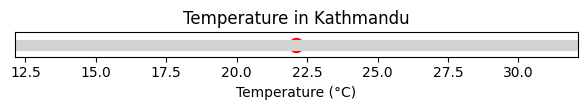

In [ ]:
#temperature
temp_min = temp_c - 10
temp_max = temp_c + 10

fig, ax = plt.subplots(figsize=(6, 1.2))
ax.plot([temp_min, temp_max], [0, 0], color="lightgray", linewidth=8)
ax.scatter(temp_c, 0, color="red", s=100)

ax.set_xlim(temp_min, temp_max)
ax.set_yticks([])
ax.set_xlabel("Temperature (°C)")
ax.set_title(f"Temperature in {city}")
plt.tight_layout()
plt.show()